We want to minimize $||Ax-b||^{2}$ w.r.t $x$
\begin{align*}
||Ax-b||^{2}= (Ax - b)^T (Ax - b)=x^T (A^T A) x - 2 b^T A x + b^T b\\
\nabla_x ||Ax-b||^{2}= 2 A^T A x - 2 A^T b\\
\end{align*}
By solving setting it to $0$ and for $x$:
\begin{align*}
A^T A x = A^T b\\
x = (A^T A)^{-1} A^T b\\
\end{align*}
In terms of linear regression $b$ is our target so it's equivalent to y. Ax is a point in column space of A, which is closest to b, so A will be matrix of inputs X and x gives us the right linear combination of column vectors of A so it's $\theta$. The closed form solution is $\theta=(X^{T}X)^{-1}X^{T}y$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#After implementing come back to test other algorithms like random forest, svm and so on.

In [2]:
class LinearRegression:
    def fit(self,X,y):
        self.X=np.asarray(X)
        self.y=np.asarray(y)
        self.theta=np.linalg.inv(X.T@X)@X.T@y
    def predict(self,X):
        X=np.asarray(X.copy())
        return X@np.reshape(self.theta,(self.theta.shape[0],1))

In [3]:
df=pd.read_csv('data/melb_data.csv')

In [4]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='str')

In [5]:
def plot_corr_matrix(data,cols=[]):
    num_cols=data.select_dtypes(exclude='object').columns
    if len(cols)!=0:
        num_cols=cols
    matrix = data[num_cols].corr()
    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    ax.set_title('Correlation Matrix')
    plt.show()

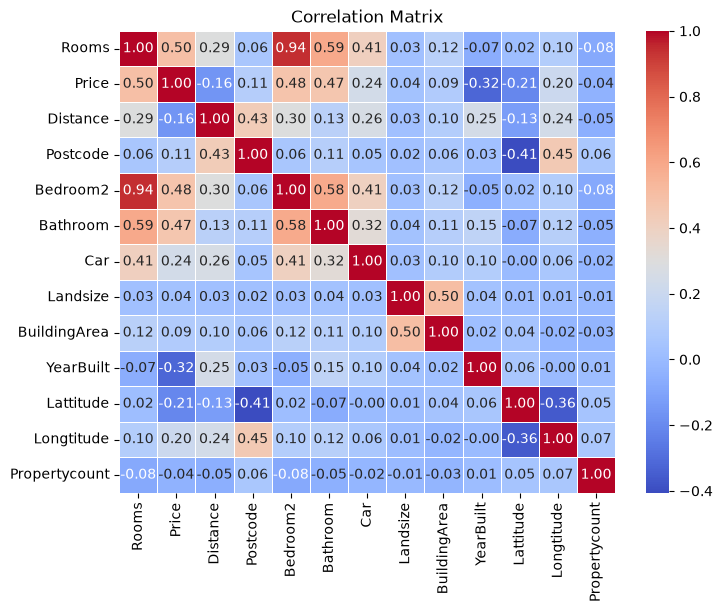

In [6]:
plot_corr_matrix(df)

In [7]:
df['BuildingArea'].describe()

count     7130.000000
mean       151.967650
std        541.014538
min          0.000000
25%         93.000000
50%        126.000000
75%        174.000000
max      44515.000000
Name: BuildingArea, dtype: float64

In [8]:
df['BuildingArea'].quantile(.999)

np.float64(1010.6480000000083)

In [9]:
df.dropna(axis=0,subset=['Car'],inplace=True)

In [10]:
# Deleted extreme outliers
df = df[((df['BuildingArea'] > 20) & (df['BuildingArea'] < 1000))|(df['BuildingArea'].isnull())]

In [11]:
df['BuildingArea']=np.log1p(df['BuildingArea'])

In [12]:
# To further optimize could use feature selection algorithm or use more features 
X=df[['Rooms','Distance','Lattitude',
       'Longtitude','Type','Regionname','BuildingArea',  'Bathroom','Car','Suburb','YearBuilt']]
y=df['Price'].astype('float64')

In [13]:
# One hot encoding of Type and Regionname
X=pd.get_dummies(X,columns=['Type','Regionname'],drop_first=True, dtype='int32')

In [14]:
X['Rooms']=X['Rooms'].astype('float64')
num_cols=X.select_dtypes(include='float64').columns

In [15]:
X.insert(0,'x0',np.ones(X.shape[0]))

In [16]:
X['YearBuilt_missing'] = X['YearBuilt'].isna().astype(int)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [18]:
# BuildingArea hadaroudn 6500 null values so i filled them based on average BuildingArea in given Suburb
Ba_median=X_train['BuildingArea'].median()
Sub_Ba=X_train.groupby('Suburb')['BuildingArea'].median()
Yb_median=X_train['YearBuilt'].median()
for Ba_val,sub in zip(Sub_Ba.values,Sub_Ba.index):
    X_train.loc[(X_train['BuildingArea'].isna())&(X_train['Suburb']==sub),'BuildingArea']=Ba_val
    X_test.loc[(X_test['BuildingArea'].isna())&(X_test['Suburb']==sub),'BuildingArea']=Ba_val
    
    
X_train['YearBuilt']=X_train['YearBuilt'].fillna(Yb_median)
X_test['YearBuilt']=X_test['YearBuilt'].fillna(Yb_median)

X_train['BuildingArea']=X_train['BuildingArea'].fillna(Ba_median)
X_test['BuildingArea']=X_test['BuildingArea'].fillna(Ba_median)

X_train.drop(columns=['Suburb'],inplace=True)
X_test.drop(columns=['Suburb'],inplace=True)

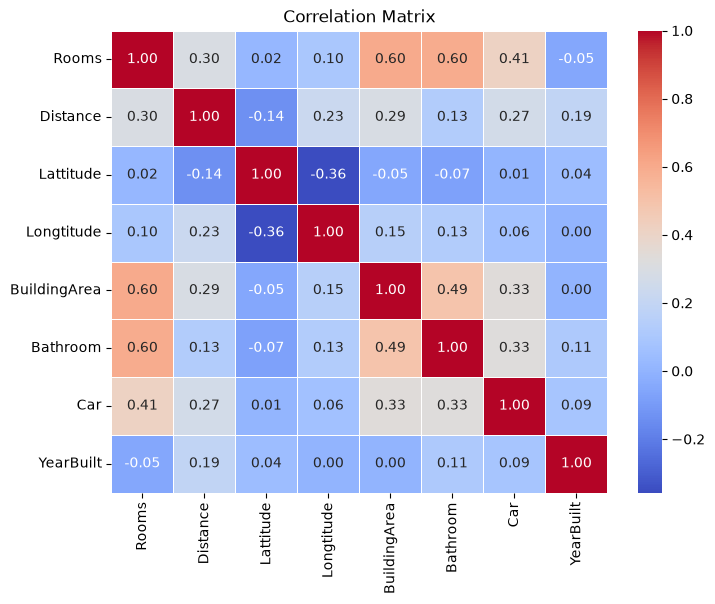

In [19]:
plot_corr_matrix(X_train,num_cols)

In [20]:
#Standarization of X_train,X_test and log of y_train
X_train_std=X_train.loc[:,num_cols].std(axis=0)
X_train_mean=X_train.loc[:,num_cols].mean(axis=0)
X_train.loc[:,num_cols]=(X_train.loc[:,num_cols]-X_train_mean)/X_train_std
X_test.loc[:,num_cols]=(X_test.loc[:,num_cols]-X_train_mean)/X_train_std

y_train_log=np.log1p(y_train)
y_train_mean=y_train_log.mean()
y_train_std=y_train_log.std()
y_train_log=(y_train_log-y_train_mean)/y_train_std


In [21]:
lr=LinearRegression()
lr.fit(X_train,y_train_log)
preds_log=lr.predict(X_test)
preds_log=(preds_log*y_train_std+y_train_mean).flatten()
preds=np.expm1(preds_log)
print(f"Average error for test set: {np.round(np.mean(np.abs(y_test.values-preds)),2)}")

Average error for test set: 229599.66


In [22]:
lr=LinearRegression()
lr.fit(X_train,y_train_log)
train_preds_log=lr.predict(X_train)
train_preds_log=(train_preds_log*y_train_std+y_train_mean).flatten()
train_preds=np.expm1(train_preds_log)
print(f"Average error for training set: {np.round(np.mean(np.abs(y_train.values-train_preds)),2)}")

Average error for training set: 223659.32


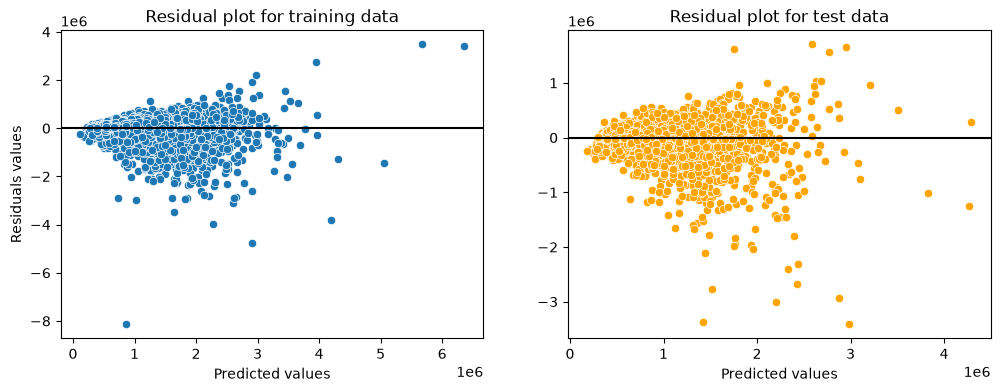

In [23]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
#train
sns.scatterplot(x=train_preds,y=train_preds-y_train,ax=ax1)
ax1.set_title('Residual plot for training data')
ax1.set_ylabel('Residuals values')#errors
#test
sns.scatterplot(x=preds,y=preds-y_test,ax=ax2,c='orange')
ax2.set_title('Residual plot for test data')
ax2.set_ylabel('')
for ax in (ax1,ax2):
    ax.axhline(0,c='black')
    ax.set_xlabel('Predicted values')
plt.show()
#We can identify substantial number of outliers